# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [49]:
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv('/content/tweet_sentiment_train.csv.zip')

In [51]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [53]:
df = df.dropna()

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [54]:
df.sentiment.value_counts(normalize=True).round(2)

,proportion
sentiment,
neutral,0.40
positive,0.31
negative,0.28


In [55]:
df['text_length'] = df['text'].str.len()

In [56]:
df.head()

,textID,text,selected_text,sentiment,text_length
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,36
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,46
2,088c60f138,my boss is bullying me...,bullying me,negative,25
3,9642c003ef,what interview! leave me alone,leave me alone,negative,31
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,75


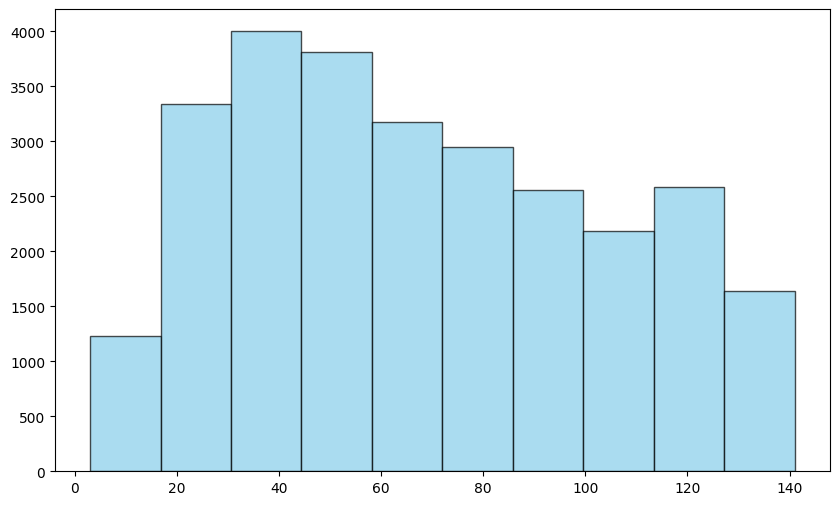

In [57]:
plt.figure(figsize=(10, 6))

plt.hist(df['text_length'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)

plt.show()

Найбільша кількість постів з довжиною тексту 40-50 символів. Розподіл трохи зміщений вліво.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [58]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
import re
import nltk

In [59]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [60]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [61]:
english_stopwords = stopwords.words('english')

In [62]:
stemmer = SnowballStemmer(language='english')

In [63]:
def preprocess_text(text):
    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-z\s]', '', text)

    tokens = word_tokenize(text)

    filtered_tokens = [
        word for word in tokens if word not in english_stopwords
    ]

    stemmed_tokens = [
        stemmer.stem(word) for word in filtered_tokens
    ]

    return ' '.join(stemmed_tokens)


In [64]:
cleaned_text = df['text'].apply(preprocess_text)

In [65]:
cleaned_text

,text
0,id respond go
1,sooo sad miss san diego
2,boss bulli
3,interview leav alon
4,son couldnt put releas alreadi bought
...,...
27476,wish could come see u denver husband lost job ...
27477,ive wonder rake client made clear net dont for...
27478,yay good enjoy break probabl need hectic weeke...
27479,worth


In [66]:
cleaned_text.values

array(['id respond go', 'sooo sad miss san diego', 'boss bulli', ...,
       'yay good enjoy break probabl need hectic weekend take care hun xxxx',
       'worth', 'flirt go atg smile yay hug'], dtype=object)

In [67]:
MAX_FEATURES = 5000

vectorizer = CountVectorizer(max_features=MAX_FEATURES)

In [68]:
vectorizer.fit(cleaned_text)

CountVectorizer(max_features=5000)

In [69]:
len(vectorizer.vocabulary_)

5000

In [70]:
vectorizer.get_feature_names_out()[:100]

array(['aaaah', 'aaah', 'aah', 'aaron', 'ab', 'abandon', 'abbi', 'abc',
       'abil', 'abit', 'abl', 'absolut', 'abt', 'ac', 'academi', 'accept',
       'access', 'accid', 'accident', 'accomplish', 'accord', 'account',
       'acct', 'ace', 'ach', 'achiev', 'acid', 'ack', 'across', 'act',
       'action', 'activ', 'actor', 'actress', 'actual', 'ad', 'adam',
       'add', 'addict', 'address', 'admir', 'admit', 'adopt', 'ador',
       'adult', 'advanc', 'advantag', 'adventur', 'advert', 'advertis',
       'advic', 'affect', 'afford', 'afraid', 'africa', 'afternoon',
       'afterward', 'age', 'agent', 'agh', 'ago', 'agre', 'ah', 'aha',
       'ahaha', 'ahahaha', 'ahead', 'ahh', 'ahhh', 'ahhhh', 'ahhhhh',
       'ahhhhhh', 'aidan', 'aiden', 'aight', 'aim', 'aint', 'air',
       'airlin', 'airport', 'aka', 'ako', 'al', 'ala', 'alarm', 'album',
       'alcohol', 'alex', 'alexi', 'algebra', 'ali', 'alic', 'alien',
       'alik', 'aliv', 'allah', 'allen', 'allerg', 'allergi', 'allll'],
     

In [71]:
inputs = vectorizer.transform(cleaned_text)

In [72]:
inputs.shape

(27480, 5000)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [73]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

In [74]:
y = df['sentiment']

In [75]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
        inputs, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

In [76]:
print(f"Розмір X_train: {X_train_bow.shape}")
print(f"Розмір X_test: {X_test_bow.shape}")

Розмір X_train: (19236, 5000)
Розмір X_test: (8244, 5000)


In [77]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_bow, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [78]:
y_pred_log = log_reg.predict(X_test_bow)

In [79]:
print(f"Точність (Accuracy): {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Точність (f1_score): {f1_score(y_test, y_pred_log, average='macro'):.4f}")

Точність (Accuracy): 0.6809
Точність (f1_score): 0.6817


In [80]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train_bow, y_train)

DecisionTreeClassifier(random_state=42)

In [81]:
y_pred_tree = tree_clf.predict(X_test_bow)

In [82]:
print(f"Точність (Accuracy): {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Точність (f1_score): {f1_score(y_test, y_pred_tree, average='macro'):.4f}")

Точність (Accuracy): 0.6328
Точність (f1_score): 0.6340


Логістична регресія в даному випадку показала кращу якість класифікації. Якість як для перших базових моделей на мою думку хороша

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [83]:
feature_importance_negative = pd.Series(log_reg.coef_[0], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance_negative[:10]

,imp
sad,2.545970
suck,2.528199
hate,2.294621
sorri,2.281748
bore,2.226082
miss,2.147262
headach,2.098321
fail,2.062653
stupid,2.045922
worst,2.044743


In [84]:
feature_importance_neutral = pd.Series(log_reg.coef_[1], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance_neutral[:10]

,imp
indoor,1.451278
how,1.352333
oooo,1.277347
jst,1.143804
otherwis,1.143532
starwarsday,1.142141
twhirl,1.122567
moro,1.119759
parvo,1.094681
pearl,1.081128


In [85]:
feature_importance_positive = pd.Series(log_reg.coef_[2], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance_positive[:10]

,imp
awesom,2.589930
thank,2.471116
cute,2.461704
love,2.432139
glad,2.284491
amaz,2.275810
gorgeous,2.181727
nice,2.162328
excit,2.138653
enjoy,2.126854


Так, все логічно

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [87]:
tfidf_vectorizer = TfidfVectorizer(max_features=MAX_FEATURES)

In [88]:
tfidf_vectorizer.fit(cleaned_text)

TfidfVectorizer(max_features=5000)

In [89]:
tfidf_inputs = tfidf_vectorizer.transform(cleaned_text)

In [90]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
        tfidf_inputs, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

In [91]:
print(f"Розмір X_train: {X_train_tfidf.shape}")
print(f"Розмір X_test: {X_test_tfidf.shape}")

Розмір X_train: (19236, 5000)
Розмір X_test: (8244, 5000)


In [92]:
tfidf_log_reg = LogisticRegression(max_iter=1000, random_state=42)
tfidf_log_reg.fit(X_train_tfidf, y_train_tfidf)

LogisticRegression(max_iter=1000, random_state=42)

In [93]:
tfidf_y_pred_log = tfidf_log_reg.predict(X_test_tfidf)

In [94]:
print(f"Точність (Accuracy): {accuracy_score(y_test_tfidf, tfidf_y_pred_log):.4f}")
print(f"Точність (f1_score): {f1_score(y_test_tfidf, tfidf_y_pred_log, average='macro'):.4f}")

Точність (Accuracy): 0.6844
Точність (f1_score): 0.6838


### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [95]:
df

,textID,text,selected_text,sentiment,text_length
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,36
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,46
2,088c60f138,my boss is bullying me...,bullying me,negative,25
3,9642c003ef,what interview! leave me alone,leave me alone,negative,31
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,75
...,...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative,77
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative,122
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive,111
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive,27


In [96]:
df['prediction'] = tfidf_log_reg.predict(tfidf_inputs)

In [97]:
df

,textID,text,selected_text,sentiment,text_length,prediction
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,36,neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,46,negative
2,088c60f138,my boss is bullying me...,bullying me,negative,25,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative,31,neutral
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,75,neutral
...,...,...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative,77,negative
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative,122,neutral
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive,111,positive
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive,27,positive


In [98]:
from sklearn.metrics import confusion_matrix

In [117]:
matrix = confusion_matrix(df.sentiment, df.prediction)

In [118]:
labels = ['Negative', 'Neutral', 'Positive']

In [116]:
from sklearn.metrics import ConfusionMatrixDisplay

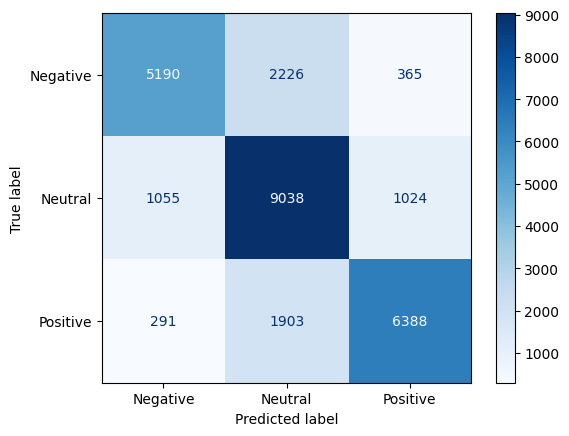

In [120]:
disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=labels)

disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.show()

Тут можна побачити, що найчастіше модель помиляється з нейтральним класом:

*   2226 разів модель помилково класифікувала Negative як Neutral
*   1903 рази модель помилково класифікувала Positive як Neutral

Зате модель добре розрізняє протилежні настрої:

*   Вона сплутала Negative з Positive лише 365 разів.
*   Вона сплутала Positive з Negative лише 291 раз.

Можливі шляхи поліпшення якості класифікації:

1.   Балансування класів (зараз записів класу neutral найбільше)
2.   Проаналізувати записи на яких модель помиляється (можливо потрібно ще якось очистити чи доповнити дані)
3.   Використати можливо більш просунуті алгоритми



І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model